# Data Visualizations

In [14]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
os.environ.setdefault("MLFLOW_TRACKING_URI", "file:///Users/dpham/mlruns_ml_pipeline")

from mlflow import MlflowClient
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.set_theme(context="paper", style="ticks", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

GREY = "#7a7a7a"
ACCENT = sns.color_palette("mako", n_colors=6)[2]

MODELS = {
    "Logistic Regression": ("logistic_regression_survey_weights", "data/test_labeled_logistic_regression.parquet"),
    "XGBoost":             ("xgboost_survey_weights",             "data/test_labeled_xgboost.parquet"),
    "Neural Network":      ("neural_network_survey_weights",      "data/test_labeled_neural_network.parquet"),
}
MODEL_ORDER = list(MODELS.keys())
VARIANTS = ("standard", "survey_weighted")
TARGET = "Disability (recoded)_With a disability"
TEST_PARQUET = "data/test.parquet"
TRUE_POSITIVE_RATE = 0.1214

# Loading most recent model results from Mlflow
client = MlflowClient()
rows = []
for model, (exp_name, _) in MODELS.items():
    exp = client.get_experiment_by_name(exp_name)
    for variant in VARIANTS:
        runs = client.search_runs(
            experiment_ids=[exp.experiment_id],
            filter_string=f"attributes.run_name = '{variant}_test'",
            order_by=["start_time DESC"],
            max_results=1,
        )
        for k, v in runs[0].data.metrics.items():
            if not k.startswith("test_"):
                continue
            _, weighting, metric = k.split("_", 2)
            rows.append({"model": model, "variant": variant,
                         "weighting": weighting, "metric": metric, "value": v})
metrics_df = pd.DataFrame(rows)

## Figure 1

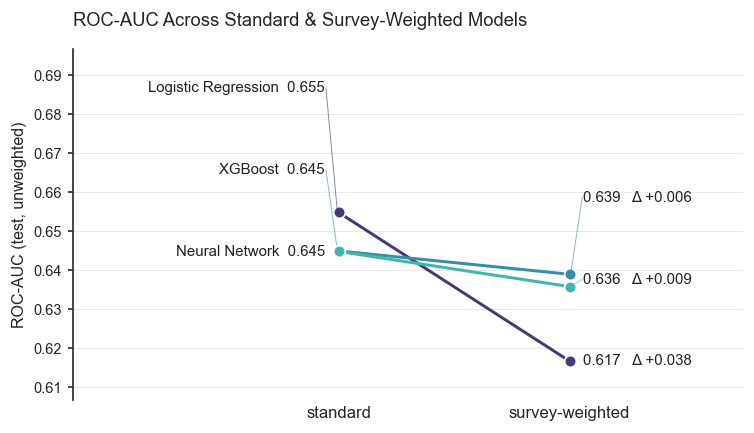

In [15]:
auc = (metrics_df[(metrics_df["metric"] == "roc_auc") & (metrics_df["weighting"] == "unweighted")]
         .pivot(index="model", columns="variant", values="value")
         .loc[MODEL_ORDER])

mako_shades = sns.color_palette("mako", n_colors=6)
model_colors = {
    "Logistic Regression": mako_shades[1],
    "XGBoost":             mako_shades[3],
    "Neural Network":      mako_shades[4],
}

def spread(y_vals, min_gap):
    order = sorted(range(len(y_vals)), key=lambda i: y_vals[i])
    out = list(y_vals)
    for k in range(1, len(order)):
        prev, cur = order[k - 1], order[k]
        if out[cur] - out[prev] < min_gap:
            out[cur] = out[prev] + min_gap
    return out

left_y  = [auc.loc[m, "standard"]        for m in MODEL_ORDER]
right_y = [auc.loc[m, "survey_weighted"] for m in MODEL_ORDER]
span = max(max(left_y + right_y) - min(left_y + right_y), 0.03)
gap  = span * 0.55
left_label_y  = spread(left_y,  gap)
right_label_y = spread(right_y, gap)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
for model, y0, y1, ly0, ly1 in zip(MODEL_ORDER, left_y, right_y, left_label_y, right_label_y):
    color = model_colors[model]
    ax.plot([0, 1], [y0, y1], marker="o", color=color, linewidth=1.8,
            markersize=7, markerfacecolor=color, markeredgecolor="white")
    ax.text(-0.06, ly0, f"{model}  {y0:.3f}",
            ha="right", va="center", fontsize=9, color="#222222")
    if abs(ly0 - y0) > 1e-4:
        ax.plot([-0.055, -0.005], [ly0, y0], color=color, linewidth=0.6, alpha=0.6)
    delta = y0 - y1
    ax.text(1.06, ly1, f"{y1:.3f}   Δ {delta:+.3f}",
            ha="left", va="center", fontsize=9, color="#222222")
    if abs(ly1 - y1) > 1e-4:
        ax.plot([1.005, 1.055], [y1, ly1], color=color, linewidth=0.6, alpha=0.6)

ax.set_xticks([0, 1])
ax.set_xticklabels(["standard", "survey-weighted"], fontsize=10)
ax.set_xlim(-1.15, 1.75)
y_lo = min(left_y + right_y + left_label_y + right_label_y) - 0.01
y_hi = max(left_y + right_y + left_label_y + right_label_y) + 0.01
ax.set_ylim(y_lo, y_hi)
ax.set_ylabel("ROC-AUC (test, unweighted)")
ax.set_title("ROC-AUC Across Standard & Survey-Weighted Models",
             loc="left", fontsize=11, pad=14)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=3)
ax.grid(axis="y", color="#e6e6e6", linewidth=0.5)
ax.set_axisbelow(True)
plt.show()

## Figure 2

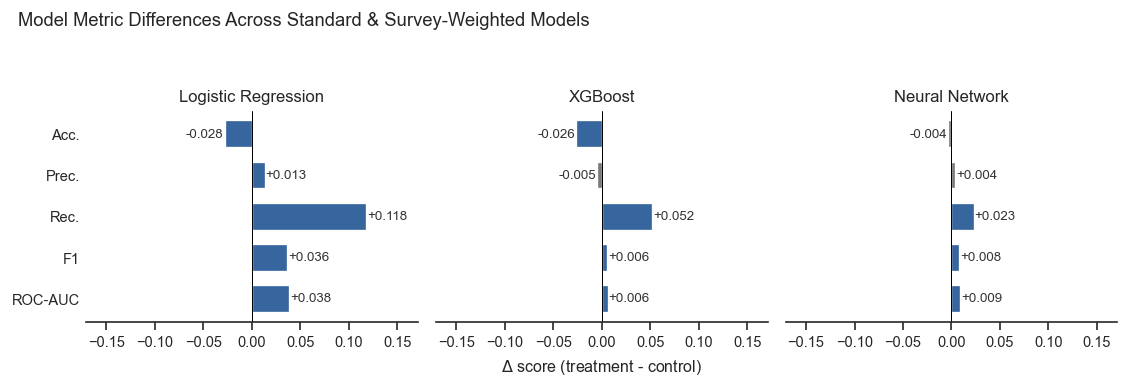

In [21]:
metric_order = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = {"accuracy": "Acc.", "precision": "Prec.", "recall": "Rec.",
                 "f1": "F1", "roc_auc": "ROC-AUC"}

delta_df = (metrics_df.pivot_table(index=["model", "weighting", "metric"],
                                   columns="variant", values="value")
                      .reset_index())
delta_df["delta"] = delta_df["standard"] - delta_df["survey_weighted"]
sub = delta_df[delta_df["weighting"] == "unweighted"]

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2), sharex=True, sharey=True)
xmax = float(sub["delta"].abs().max()) * 1.45
for ax, model in zip(axes, MODEL_ORDER):
    row = sub[sub["model"] == model].set_index("metric").loc[metric_order]
    colors = [ACCENT if abs(d) > 0.005 else GREY for d in row["delta"]]
    y_labels = [metric_labels[m] for m in metric_order]
    ax.barh(y_labels, row["delta"].values, color=colors, height=0.65)
    for y, d in zip(range(len(y_labels)), row["delta"].values):
        ax.text(d + (0.001 if d >= 0 else -0.001), y, f"{d:+.3f}",
                ha="left" if d >= 0 else "right", va="center", fontsize=8,
                color="#333333")
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_title(model, fontsize=10)
    ax.set_xlim(-xmax, xmax)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.invert_yaxis()
axes[1].set_xlabel(r"$\Delta$ score (treatment - control)")
fig.suptitle("Model Metric Differences Across Standard & Survey-Weighted Models",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Figure 3

In [17]:
labeled = {name: pl.read_parquet(parquet) for name, (_, parquet) in MODELS.items()}
state_pop = pl.read_parquet(TEST_PARQUET, columns=["State population"])["State population"].to_numpy()

rate_rows = []
for model, df in labeled.items():
    for variant in VARIANTS:
        pred = df[f"predicted_disability_{variant}"].to_numpy()
        rate_rows.append({"model": model, "variant": variant, "weighting": "unweighted",
                          "rate": float(pred.mean())})
        rate_rows.append({"model": model, "variant": variant, "weighting": "population-weighted",
                          "rate": float((pred * state_pop).sum() / state_pop.sum())})
rate_df = pd.DataFrame(rate_rows)

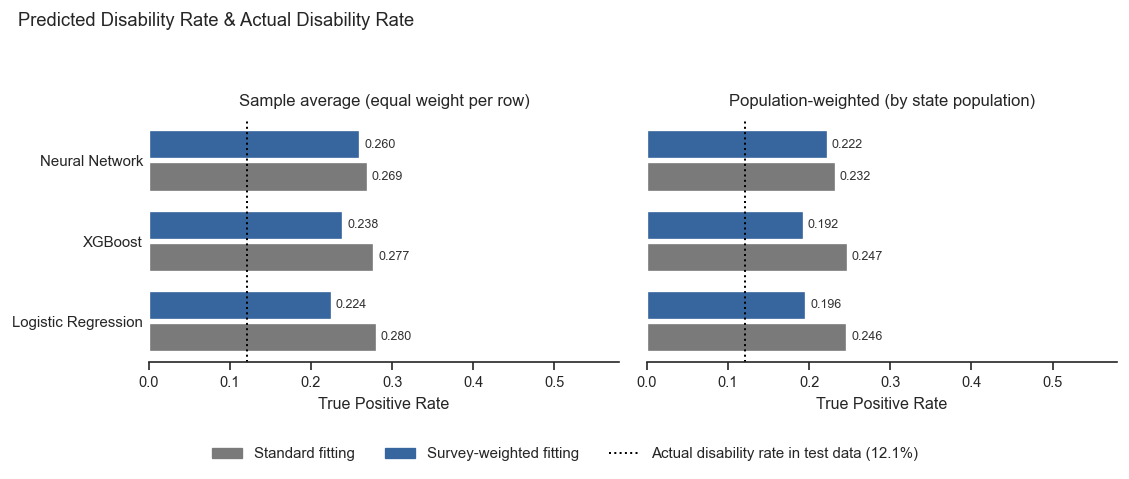

In [18]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharex=True, sharey=True)
y = np.arange(len(MODEL_ORDER))
subtitle_map = {
    "unweighted":          "Sample average (equal weight per row)",
    "population-weighted": "Population-weighted (by state population)",
}
for ax, weighting in zip(axes, ["unweighted", "population-weighted"]):
    sub = rate_df[rate_df["weighting"] == weighting]
    for j, variant in enumerate(VARIANTS):
        rates = [sub[(sub["model"] == m) & (sub["variant"] == variant)]["rate"].iloc[0]
                 for m in MODEL_ORDER]
        color = GREY if variant == "standard" else ACCENT
        offset = -0.2 if j == 0 else 0.2
        ax.barh(y + offset, rates, height=0.35, color=color)
        for i, r in enumerate(rates):
            ax.text(r + 0.006, i + offset, f"{r:.3f}", va="center",
                    fontsize=7.5, color="#333333")
    ax.axvline(TRUE_POSITIVE_RATE, color="black", linestyle=":", linewidth=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(MODEL_ORDER, fontsize=9)
    ax.set_xlim(0, 0.58)
    ax.set_xlabel("True Positive Rate")
    ax.set_title(subtitle_map[weighting], fontsize=10, pad=8)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.invert_yaxis()

handles = [
    Patch(color=GREY,   label="Standard fitting"),
    Patch(color=ACCENT, label="Survey-weighted fitting"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.2,
           label=f"Actual disability rate in test data ({TRUE_POSITIVE_RATE:.1%})"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
           ncol=3, frameon=False, fontsize=9)

fig.suptitle("Predicted Disability Rate & Actual Disability Rate",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

## Figure 4

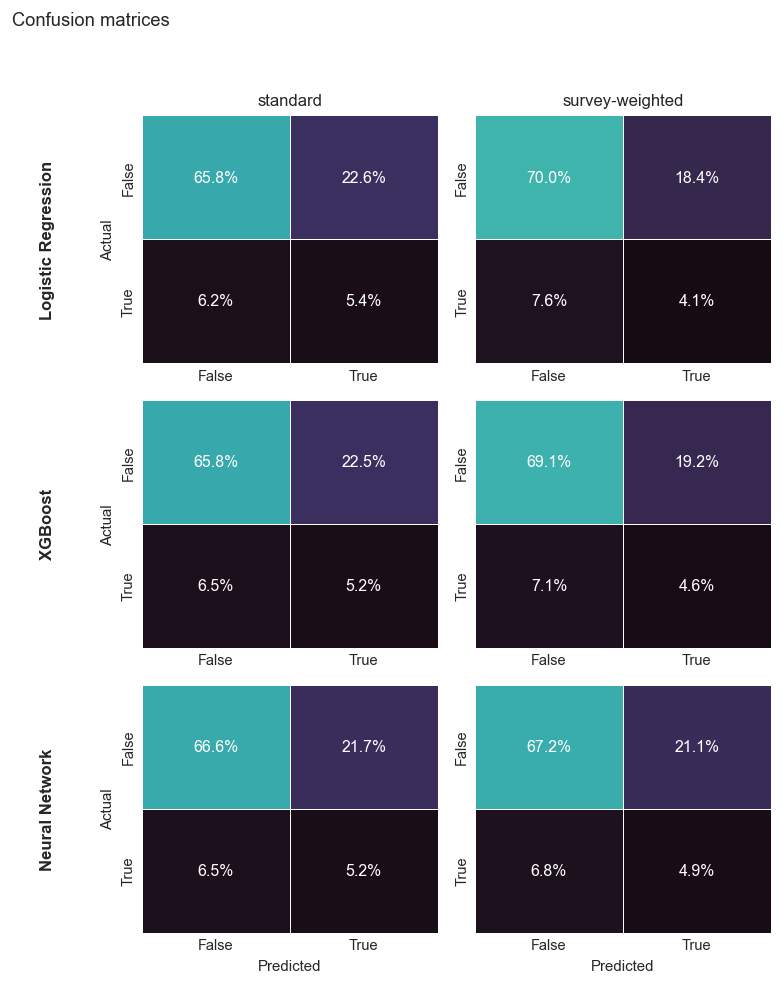

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(6.6, 8.2))
for i, (model, df) in enumerate(labeled.items()):
    y = df[TARGET].to_numpy()
    for j, variant in enumerate(VARIANTS):
        pred = df[f"predicted_disability_{variant}"].to_numpy()
        cm = confusion_matrix(y, pred, normalize="all") * 100
        annot = np.array([[f"{v:.1f}%" for v in row] for row in cm])
        sns.heatmap(cm, annot=annot, fmt="", cmap="mako", ax=axes[i, j],
                    cbar=False, vmin=0, vmax=100,
                    xticklabels=["False", "True"], yticklabels=["False", "True"],
                    annot_kws={"color": "white", "fontsize": 9.5},
                    linewidths=0.3, linecolor="white")
        if i == 0:
            axes[i, j].set_title(variant.replace("_", "-"), fontsize=10)
        axes[i, j].set_xlabel("Predicted" if i == 2 else "", fontsize=9)
        if j == 0:
            axes[i, j].set_ylabel("Actual", fontsize=9)
            axes[i, j].annotate(model, xy=(-0.32, 0.5), xycoords="axes fraction",
                                ha="center", va="center", rotation=90,
                                fontsize=10, fontweight="bold")
        else:
            axes[i, j].set_ylabel("")
        axes[i, j].tick_params(length=0)

fig.suptitle("Confusion matrices",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0.04, 0, 1, 0.965])
plt.show()